In [41]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

# ── configure run ─────────────────────────────────────────────────────────────
RUN_DIR = Path("../results/baseline_olympiad_gpt41_n50_20260609")
# ─────────────────────────────────────────────────────────────────────────────

RESULTS_DIR = RUN_DIR / "saved_results"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [42]:
# Load predictions and metadata
pred = pd.read_csv(RESULTS_DIR / "predictions.csv")
summary = pd.read_csv(RESULTS_DIR / "summary.csv")

with open(RUN_DIR / "parsed_traces.json") as f:
    parsed = json.load(f)

meta = pd.DataFrame([
    {"trace_id": t["metadata"]["trace_id"], "correct": t["metadata"]["correct"]}
    for t in parsed
])

df = pred.merge(meta, on="trace_id", how="left")

FM_CODES = ["1.1","1.2","1.3","1.4","1.5",
            "2.1","2.2","2.3","2.4","2.5","2.6",
            "3.1","3.2","3.3"]

FM_NAMES = {
    "1.1": "Disobey Task Specification",
    "1.2": "Disobey Role Specification",
    "1.3": "Step Repetition",
    "1.4": "Loss of Conversation History",
    "1.5": "Unaware of Termination Conditions",
    "2.1": "Conversation Reset",
    "2.2": "Fail to Ask for Clarification",
    "2.3": "Task Derailment",
    "2.4": "Information Withholding",
    "2.5": "Ignored Other Agent's Input",
    "2.6": "Action-Reasoning Mismatch",
    "3.1": "Premature Termination",
    "3.2": "No or Incorrect Verification",
    "3.3": "Weak Verification",
}

n_traces = len(df)
print(f"Loaded {n_traces} traces  |  correct: {df['correct'].sum()}  |  incorrect: {(~df['correct']).sum()}")
summary

Loaded 49 traces  |  correct: 32  |  incorrect: 17


,name,model,total_cost_usd,mean_cost_usd,total_latency_s,mean_latency_s
0,olympiad_gemini25flash_zero_shot,gemini-2.5-flash,0.0,0.0,732.104578,14.94091


## 1. Failure Mode Distribution

In [43]:
counts = df[FM_CODES].sum().astype(int)
pcts   = (counts / n_traces * 100).round(1)

dist = pd.DataFrame({
    "FM":    FM_CODES,
    "Name":  [FM_NAMES[c] for c in FM_CODES],
    "Count": counts.values,
    "%":     pcts.values,
})

dist

,FM,Name,Count,%
0,1.1,Disobey Task Specification,9,18.4
1,1.2,Disobey Role Specification,0,0.0
2,1.3,Step Repetition,2,4.1
3,1.4,Loss of Conversation History,0,0.0
4,1.5,Unaware of Termination Conditions,1,2.0
5,2.1,Conversation Reset,0,0.0
6,2.2,Fail to Ask for Clarification,1,2.0
7,2.3,Task Derailment,0,0.0
8,2.4,Information Withholding,0,0.0
9,2.5,Ignored Other Agent's Input,0,0.0


## 2. FM Prevalence Bar Chart

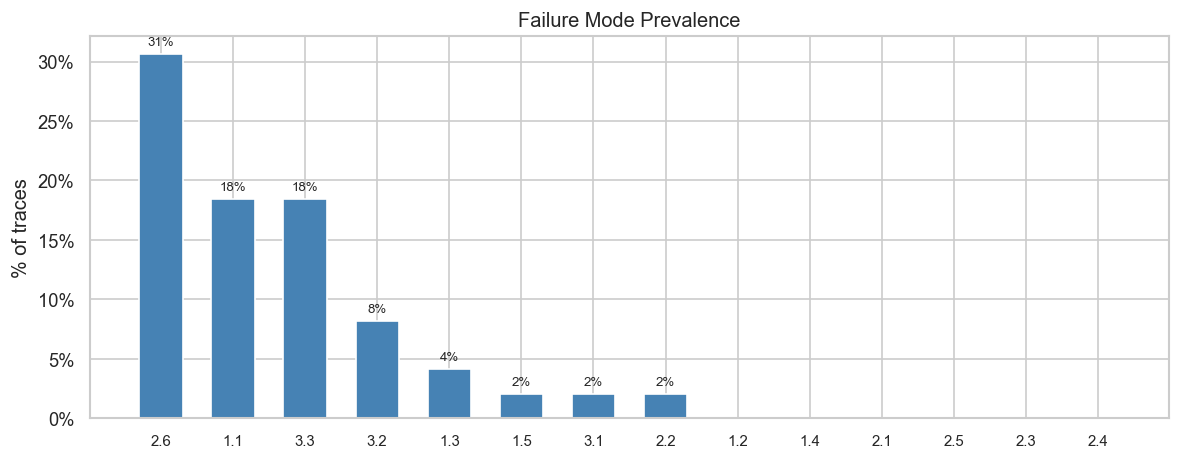

In [44]:
sorted_dist = dist.sort_values("%", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(sorted_dist)), sorted_dist["%"], color="steelblue", width=0.6)

ax.set_xticks(range(len(sorted_dist)))
ax.set_xticklabels(sorted_dist["FM"], fontsize=9)
ax.set_ylabel("% of traces")
ax.set_title("Failure Mode Prevalence")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

for bar, val in zip(bars, sorted_dist["%"]):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fm_prevalence.pdf", bbox_inches="tight")
plt.show()

## 3. Accuracy vs FM Presence

In [45]:
rows = []
for code in FM_CODES:
    with_fm    = df[df[code] == 1]
    without_fm = df[df[code] == 0]
    fail_with    = (1 - with_fm["correct"]).mean()    * 100 if len(with_fm)    > 0 else float("nan")
    fail_without = (1 - without_fm["correct"]).mean() * 100 if len(without_fm) > 0 else float("nan")
    rows.append({
        "code":         code,
        "name":         FM_NAMES[code],
        "n_with":       len(with_fm),
        "fail_with":    fail_with,
        "fail_without": fail_without,
        "delta":        fail_with - fail_without,
    })

acc_df = pd.DataFrame(rows).sort_values("fail_with", ascending=False).reset_index(drop=True)
acc_df.style.format({"fail_with": "{:.1f}%", "fail_without": "{:.1f}%", "delta": "{:+.1f}pp"}, na_rep="—")

,code,name,n_with,fail_with,fail_without,delta
0,2.2,Fail to Ask for Clarification,1,100.0%,33.3%,+66.7pp
1,1.5,Unaware of Termination Conditions,1,100.0%,33.3%,+66.7pp
2,3.1,Premature Termination,1,100.0%,33.3%,+66.7pp
3,3.3,Weak Verification,9,77.8%,25.0%,+52.8pp
4,2.6,Action-Reasoning Mismatch,15,66.7%,20.6%,+46.1pp
5,1.1,Disobey Task Specification,9,66.7%,27.5%,+39.2pp
6,1.3,Step Repetition,2,50.0%,34.0%,+16.0pp
7,3.2,No or Incorrect Verification,4,50.0%,33.3%,+16.7pp
8,1.2,Disobey Role Specification,0,—,34.7%,—
9,1.4,Loss of Conversation History,0,—,34.7%,—


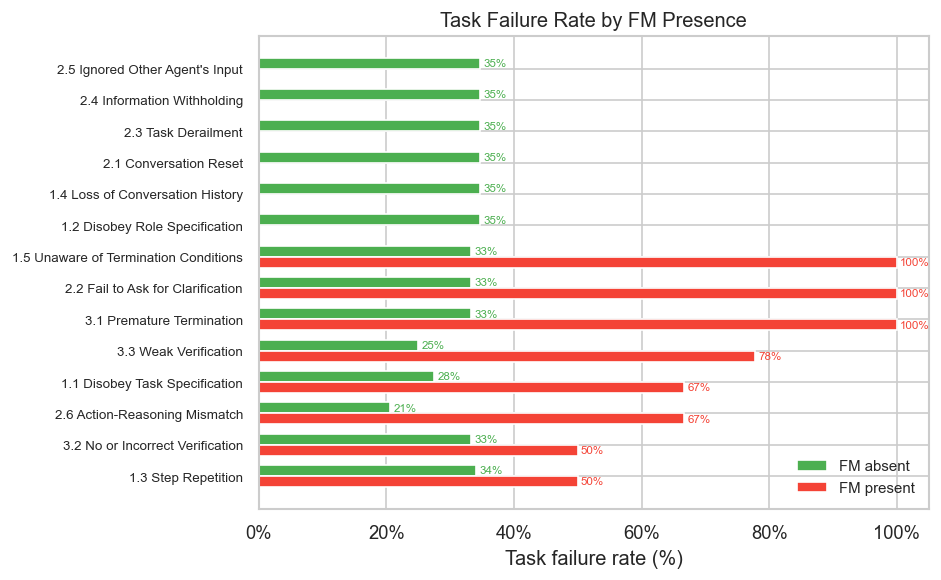

In [46]:
plot_df = acc_df.sort_values("fail_with", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))

y = np.arange(len(plot_df))
h = 0.35
ylabels = [f"{r['code']} {r['name']}" for _, r in plot_df.iterrows()]

ax.barh(y + h/2, plot_df["fail_without"], h, label="FM absent",  color="#4CAF50")
ax.barh(y - h/2, plot_df["fail_with"],    h, label="FM present", color="#F44336")

ax.set_yticks(y)
ax.set_yticklabels(ylabels, fontsize=8)
ax.set_xlabel("Task failure rate (%)")
ax.set_title("Task Failure Rate by FM Presence")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend(frameon=False, fontsize=9)

for i, row in plot_df.iterrows():
    if not np.isnan(row["fail_with"]):
        ax.text(row["fail_with"] + 0.5, i - h/2,
                f"{row['fail_with']:.0f}%", va="center", fontsize=7, color="#F44336")
    if not np.isnan(row["fail_without"]):
        ax.text(row["fail_without"] + 0.5, i + h/2,
                f"{row['fail_without']:.0f}%", va="center", fontsize=7, color="#4CAF50")

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fm_accuracy.pdf", bbox_inches="tight")
plt.show()

## 4. Summary

In [47]:
most_prevalent     = dist.loc[dist["Count"].idxmax()]
most_correlated    = acc_df.dropna(subset=["delta"]).loc[acc_df.dropna(subset=["delta"])["delta"].idxmax()]
baseline_fail_rate = (1 - df["correct"]).mean() * 100

print(f"Traces evaluated  : {n_traces}")
print(f"Baseline fail rate: {baseline_fail_rate:.1f}%")
print()
print(f"Most prevalent FM : {most_prevalent['FM']} {most_prevalent['Name']}")
print(f"  → present in {most_prevalent['Count']} / {n_traces} traces ({most_prevalent['%']:.1f}%)")
print()
print(f"FM most correlated with failure : {most_correlated['code']} {most_correlated['name']}")
print(f"  → failure rate with FM: {most_correlated['fail_with']:.1f}%  |  without: {most_correlated['fail_without']:.1f}%  |  Δ = +{most_correlated['delta']:.1f}pp")

Traces evaluated  : 49
Baseline fail rate: 34.7%

Most prevalent FM : 2.6 Action-Reasoning Mismatch
  → present in 15 / 49 traces (30.6%)

FM most correlated with failure : 2.2 Fail to Ask for Clarification
  → failure rate with FM: 100.0%  |  without: 33.3%  |  Δ = +66.7pp
